In [1]:
import os
import sys

path_add = r"C:\Users\GreenBird\Documents\GitHub\ColibriPipeline\ColibriPipeline"
if path_add not in sys.path:
    sys.path.append(path_add)

import colibri_image_reader as cir

36
x_coordinate: 984.8175468454797, y_coordinate: 1333.3965428935567


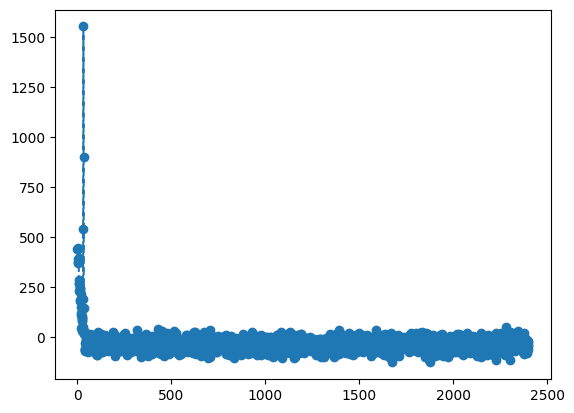

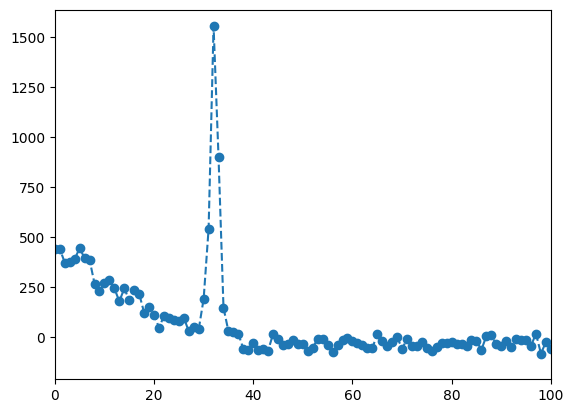

In [95]:
data_loc = r"B:\LongTermStorage\PipelineTesting\ColibriArchive\2024-10-19"
file = r"20241020_00.07.21.489_stars.npy"
pos = r"20241020_00.07.21.489_3.3sig_pos.npy"
star = 36

import numpy as np
data = np.load(os.path.join(data_loc, file), allow_pickle=True)
pos = np.load(os.path.join(data_loc, pos), allow_pickle=True)


star_data = data[:, star, :]
xpoints, ypoints, flux, time = star_data[:, 0], star_data[:, 1], star_data[:, 2], star_data[:, 3]
x_coordinate = xpoints[0] # coordinates from the light curve file
y_coordinate = ypoints[0] # coordinates from the light curve file

# Find where in the position file the coordinates are
index = np.where((pos[:, 0] == x_coordinate) & (pos[:, 1] == y_coordinate))[0][0]
print(index)
# print the coordinates
print(f"x_coordinate: {x_coordinate}, y_coordinate: {y_coordinate}")



frames = range(len(x))
import matplotlib.pyplot as plt

plt.plot(frames, flux, marker="o", linestyle="--")
plt.show()
plt.plot(frames, flux, marker="o", linestyle="--")
plt.xlim(0, 100)
plt.show()


# looking at light curve before

In [93]:
file_before = r"20241020_00.06.20.755_stars.npy"
pos_before = r"20241020_00.06.20.755_3.3sig_pos.npy"

pos_data_before = np.load(os.path.join(data_loc, pos_before), allow_pickle=True)
stellar_data = np.load(os.path.join(data_loc, file_before), allow_pickle=True)


index = np.where((abs(pos_data_before[:, 0] - x_coordinate) < 50) & 
                 (abs(pos_data_before[:, 1] - y_coordinate) < 50))[0][0]

print(index)

# index = 13

star_data_before = stellar_data[:, index, :]
xpoints_before, ypoints_before, flux_before, time_before = star_data_before[:, 0], star_data_before[:, 1], star_data_before[:, 2], star_data_before[:, 3]

xpoint_before = xpoints_before[0] # coordinates from the light curve file
ypoint_before = ypoints_before[0] # coordinates from the light curve file



# concatenate the two arrays
fluxes_combined = np.concatenate((flux_before, flux))

frames_full = range(len(fluxes_combined))
plt.plot(frames_full, fluxes_combined, marker="o", linestyle="--")
plt.axvline(2398.5, color='red')
plt.xlim(2300, 2500)


IndexError: index 0 is out of bounds for axis 0 with size 0

star didn't exist in previous frame

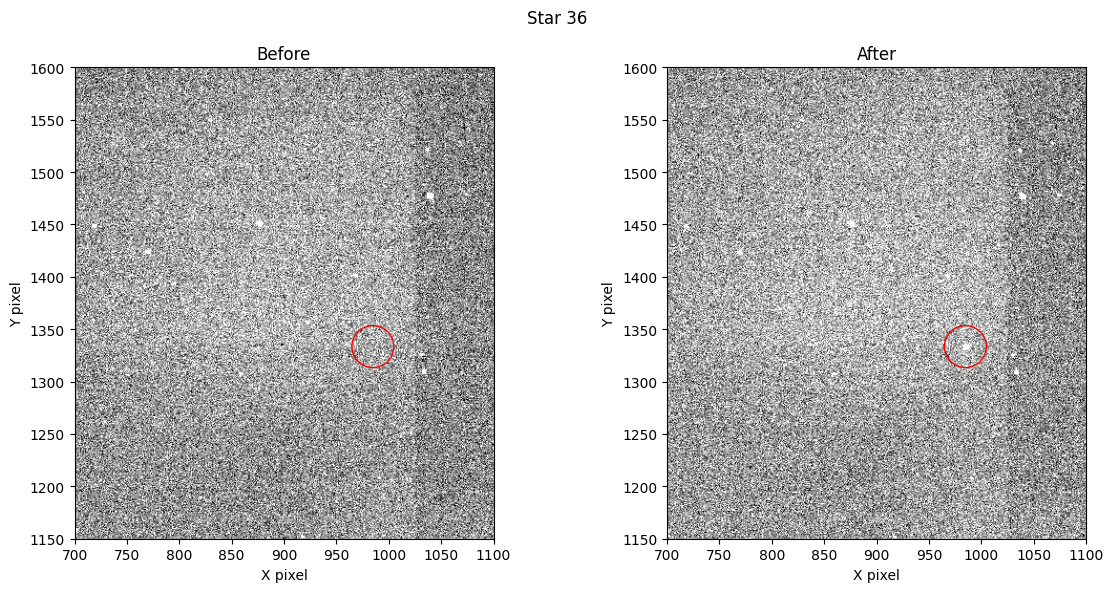

In [94]:
image_before = r"high20241020_00.06.20.755_medstacked.fits"
image_after = r"high20241020_00.07.21.489_medstacked.fits"
import astropy.io.fits as fits

image_before = fits.open(os.path.join(data_loc, image_before))
image_after = fits.open(os.path.join(data_loc, image_after))

# plot both images side by side, with a circle over the star using the respective coordinates

import matplotlib.patches as patches
import numpy as np

# Calculate vmin and vmax for better contrast
vmin_before = np.percentile(image_before[0].data, 1)  # 5th percentile
vmax_before = np.percentile(image_before[0].data, 95)  # 95th percentile
vmin_after = np.percentile(image_after[0].data, 1)  # 5th percentile
vmax_after = np.percentile(image_after[0].data, 95)  # 95th percentile

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Star {star}")

# Plot the "Before" image with improved contrast
ax1.imshow(image_before[0].data, cmap='gray', vmin=vmin_before, vmax=vmax_before)
ax1.set_title("Before")
ax1.set_xlabel("X pixel")
ax1.set_ylabel("Y pixel")
ax1.add_patch(patches.Circle((x_coordinate, y_coordinate), 20, color='red', fill=False))
ax1.set_xlim(700, 1100)
ax1.set_ylim(1150, 1600)

# Plot the "After" image with improved contrast
ax2.imshow(image_after[0].data, cmap='gray', vmin=vmin_after, vmax=vmax_after)
ax2.set_title("After")
ax2.set_xlabel("X pixel")
ax2.set_ylabel("Y pixel")
ax2.add_patch(patches.Circle((x_coordinate, y_coordinate), 20, color='red', fill=False))
ax2.set_xlim(700, 1100)
ax2.set_ylim(1150, 1600)

plt.tight_layout()
plt.show()

images suggest its a satellite